In [1]:
import StableDiffusion.ModelConverter
from StableDiffusion.DiffusionProcess import DiffusionProcess
device = 'cuda'
idleDevice = 'cpu'
diffusionDict = StableDiffusion.ModelConverter.load_from_standard_weights(input_file='../models/sd15models/v1-5-pruned-emaonly.ckpt',\
                                                            device = 'cuda')
clipWeights=diffusionDict['clip']
diffusionWeights = diffusionDict['diffusion']
vaeEncoderWeights = diffusionDict['encoder']
vaeDecoderWeights = diffusionDict['decoder']

import torch
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
filePath ="../models/ControlNet-v1-1/control_v11p_sd15_canny.pth" 
controlnetCannyDict  = torch.load(filePath, map_location= device)

import torch 
import StableDiffusion.VaeEncoder 
import StableDiffusion.VaeDecoder
import StableDiffusion.ClipEncoder
import StableDiffusion.DiffusionProcess
import importlib
importlib.reload(StableDiffusion.VaeEncoder)
importlib.reload(StableDiffusion.VaeDecoder)
importlib.reload(StableDiffusion.ClipEncoder)
importlib.reload(StableDiffusion.DiffusionProcess)
from StableDiffusion.VaeDecoder import VaeDecoder
from StableDiffusion.VaeEncoder import VaeEncoder
from StableDiffusion.ClipEncoder import ClipEncoder
from StableDiffusion.DiffusionProcess import DiffusionProcess
clipEncoder = ClipEncoder().to(device)
vaeEncoder = VaeEncoder().to(device)
vaeDecoder = VaeDecoder().to(device)
diffusionProcess = DiffusionProcess().to(device)
clipEncoder.load_state_dict(clipWeights,strict=True)
vaeEncoder.load_state_dict(vaeEncoderWeights ,strict=True)
vaeDecoder.load_state_dict(vaeDecoderWeights,strict=True)
diffusionProcess.load_state_dict(diffusionWeights,strict=True)



import StableDiffusion.ControlnetSD
import StableDiffusion.DiffusionProcessControlnet
importlib.reload(StableDiffusion.ControlnetSD)
importlib.reload(StableDiffusion.DiffusionProcessControlnet)
from StableDiffusion.ControlnetSD import ControlnetSD
from StableDiffusion.DiffusionProcessControlnet import DiffusionProcessControlnet


diffusionProcessControlnet = DiffusionProcessControlnet().to(device)
diffusionProcessControlnet.load_state_dict(diffusionWeights,strict=False)
diffusionProcessControlnet.loadControlnetWeightsDict(controlnetCannyDict)

/home/aistudio/external-libraries/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

torch.Size([1, 3, 512, 512])


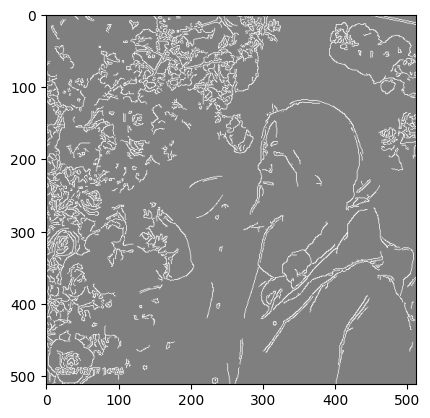

In [3]:
import cv2
import StableDiffusion.Utils
import StableDiffusion.CannyEdgeDetection
import importlib
importlib.reload(StableDiffusion.Utils)
importlib.reload(StableDiffusion.CannyEdgeDetection)
from StableDiffusion.Utils import Utils
from StableDiffusion.CannyEdgeDetection import CannyEdgeDetection
from StableDiffusion.CannyToLatent import CannyToLatent
from StableDiffusion.ControlnetTimeEmbedding import ControlnetTimeEmbedding
from StableDiffusion.ZeroConvLayer import ZeroConvLayer

filePath = './images/pusiyue_rose_1024_1024.jpg'
img = cv2.imread(filePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
cannyDetector = CannyEdgeDetection()
edgeImg = cannyDetector(img)
print(edgeImg.shape)
Utils.showBatchImage(edgeImg)
controlHint = edgeImg.to(device)

In [13]:
time = np.array([1])
timesteps =time[None]
print(timesteps.shape)

(1, 3)


torch.Size([1, 3, 512, 512])


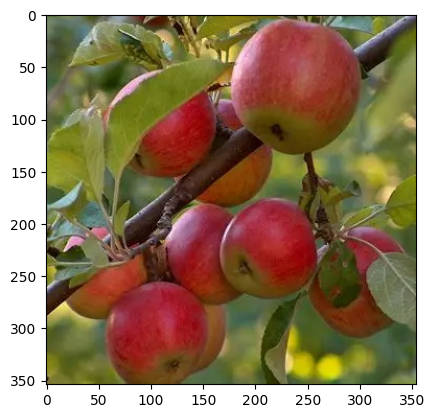

torch.Size([1, 3, 512, 512])


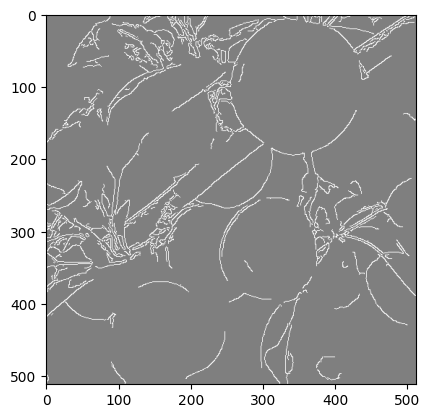

token embedding shape torch.Size([1, 77, 768])
token embedding shape torch.Size([1, 77, 768])
input image is none,use random noise instead
timesteps typetorch.int64


  0%|          | 0/20 [00:00<?, ?it/s]

timesteps  0%|          | 0/20 [00:00<?, ?it/s]
time 950 torch.Size([]) torch.int64
lantex.shape after unet torch.Size([2, 4, 64, 64])
latent shape torch.Size([2, 320, 64, 64]) cannyLatent shape torch.Size([1, 320, 64, 64])
controlOutputs.length 13


  5%|▌         | 1/20 [00:00<00:04,  4.17it/s]

time 900 torch.Size([]) torch.int64
lantex.shape after unet torch.Size([2, 4, 64, 64])
latent shape torch.Size([2, 320, 64, 64]) cannyLatent shape torch.Size([1, 320, 64, 64])
controlOutputs.length 13


...

 90%|█████████ | 18/20 [00:06<00:00,  2.81it/s]

time 50 torch.Size([]) torch.int64
lantex.shape after unet torch.Size([2, 4, 64, 64])
latent shape torch.Size([2, 320, 64, 64]) cannyLatent shape torch.Size([1, 320, 64, 64])
controlOutputs.length 13


 95%|█████████▌| 19/20 [00:06<00:00,  2.82it/s]

time 0 torch.Size([]) torch.int64
lantex.shape after unet torch.Size([2, 4, 64, 64])
latent shape torch.Size([2, 320, 64, 64]) cannyLatent shape torch.Size([1, 320, 64, 64])
controlOutputs.length 13


100%|██████████| 20/20 [00:06<00:00,  2.87it/s]


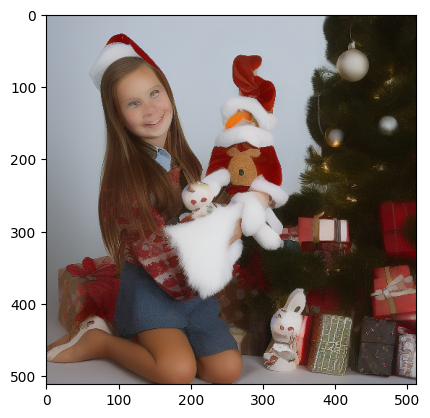

In [11]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
from torchvision import transforms
from tqdm import tqdm
import torch
from transformers import CLIPTokenizer
import numpy as np
from StableDiffusion.Utils import Utils
import matplotlib.pyplot as plt
import StableDiffusion.DdpmSamplerTorch
import StableDiffusion.TimeEmbedding
import StableDiffusion.Utils
import StableDiffusion.UnetGlobalCrossAttentionBlock
import StableDiffusion.UnetDenoise
import importlib
importlib.reload(StableDiffusion.DdpmSamplerTorch)
importlib.reload(StableDiffusion.TimeEmbedding)
importlib.reload(StableDiffusion.Utils)
importlib.reload(StableDiffusion.UnetGlobalCrossAttentionBlock)
importlib.reload(StableDiffusion.UnetDenoise)
from StableDiffusion.DdpmSamplerTorch import DdpmSamplerTorch
from StableDiffusion.TimeEmbedding import TimeEmbedding
from StableDiffusion.Utils import Utils
from StableDiffusion.UnetGlobalCrossAttentionBlock import UnetGlobalCrossAttentionBlock
from StableDiffusion.UnetDenoise import UnetDenoise
#img1 = cv2.imread('./images/pusiyue_front_1024_1024.jpg')
#img1 = cv2.imread('./images/apple.jpg')
filePath = './images/apple.jpg'
#filePath ='./images/pusiyue_front_1024_1024.jpg'
imgBatch = Utils.loadImageBatch(filePath)
#filePath = './images/pusiyue_rose_1024_1024.jpg'
img = cv2.imread(filePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
cannyDetector = CannyEdgeDetection()
edgeImg = cannyDetector(img)
print(edgeImg.shape)
Utils.showBatchImage(edgeImg)
controlHint = edgeImg.to(device)



Width = 512
Height = 512
LatentWidth = Width//8
LatentHeight = Height//8
LatentShape = (1,4,LatentHeight,LatentWidth)
#LatentShape = (4,4,LatentHeight,LatentWidth)
imgBatch = imgBatch.to(device)
inputImage = imgBatch
inputImage = None
isDoingCfg = True
isDoingContorlnet = True
#isDoingCfg = True
numInferenceSteps = 20
#cfgScale = 7.5
cfgScale = 7.5
seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# This forces the GPU to use slower, deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

randomGenerator = torch.Generator(device=device)
randomGenerator.manual_seed(seed)
sampler = DdpmSamplerTorch(randomGenerator=randomGenerator,
                           numTrainingSteps=1000,
                           numInferenceSteps=numInferenceSteps)
promptPositive = [
        '1girl, solo, long_hair, looking_at_viewer, brown_hair, \
            hair_ornament, holding, jacket, black_eyes, lips,\
        stuffed_toy, scrunchie, stuffed_animal, christmas, \
            realistic, stuffed_bunny, carrot, christmas_tree, christmas_ornaments'  #wd14 tag
       
        ]
promptNegative =['lowres, {bad}, error, fewer, extra,\
                 missing, worst quality, jpeg artifacts, \
                 bad quality, watermark, unfinished, \
                displeasing, chromatic aberration, signature, \
                    extra digits, artistic error, username, \
                        scan, [abstract]']
promptPositiveTokens,attentionMaskPositive = Utils.getPromptTokens(promptPositive,device=device)
promptNegativeTokens,attentionMaskNegative = Utils.getPromptTokens(promptNegative,device=device)
clipInputsPositive =promptPositiveTokens
clipInputsNegative = promptNegativeTokens
vaeEncoder.eval()
vaeDecoder.eval()
diffusionProcess.eval()
diffusionProcessControlnet.eval()
clipEncoder.eval()
imgStepList = []
with torch.no_grad():
    clipOutputsPositive = clipEncoder(clipInputsPositive,attentionMask = attentionMaskPositive)
    clipOutputsNegative = clipEncoder(clipInputsNegative,attentionMask = attentionMaskNegative)   
    #clipOutputsPositive = clipEncoder(clipInputsPositive,attentionMask = None)
    #clipOutputsNegative = clipEncoder(clipInputsNegative,attentionMask = None) 
    #print(clipOutputs)
    
    if isDoingCfg == True:
        clipOutputs = torch.cat([clipOutputsPositive,clipOutputsNegative])
    else:
        clipOutputs = clipOutputsPositive
        
    
    if inputImage is not None:
        
        print(f'use input image to guide image generation')
        inputNoise =torch.randn(LatentShape,generator=randomGenerator,device=device)      
        #inputNoise = None
        latentNoised = vaeEncoder(inputImage,inputNoise)
        sampler.setAddNoiseStrength(0.3)
        time = sampler.getInferenceTimeSteps()[0].to(device)
        latentNoised = sampler.addNoise(latentNoised,time)
        imageDecodedDirect = vaeDecoder(latentNoised)       
        Utils.showBatchImage(imageDecodedDirect)
        
    else: 
        print(f'input image is none,use random noise instead')
        latentNoised = torch.randn(LatentShape,generator=randomGenerator,device=device)
    
    timesteps = sampler.getInferenceTimeSteps() 
    print(f'timesteps type{timesteps.dtype}')       
    
    timesteps = tqdm(timesteps)
    print(f'timesteps{timesteps}')
    for i,time in enumerate(timesteps):
        #print(f'i step: {i} time step: {time} {time.device}')              
        timeEmbedding320 = Utils.getTimeEmbedding(time)    
        timeEmbedding320= sampler.numpy2Tensor(timeEmbedding320,device=device)
        modelNoisedLatentInput = latentNoised
        contextInput = clipOutputs
        if isDoingCfg == True:
            #print(f'is doing cfg scale {cfgScale}')
            modelNoisedLatentInput = modelNoisedLatentInput.repeat(2,1,1,1)
            #print(f'doing cfg scale latent inputs shape  {modelNoisedLatentInput.shape}') 
        
        #print(f'latentinput device: {modelNoisedLatentInput.device}  contextinput device: {contextInput.device} timeembed device: {timeEmbedding320.device}')
        #print(f'latent input: {modelNoisedLatentInput} contextinput: {contextInput} timeinput: {timeEmbedding320}')
        #print(f'latent input: {modelNoisedLatentInput.shape} contextinput: {contextInput.shape} timeinput: {timeEmbedding320.shape}')
        if isDoingContorlnet == False:
            modelEstimatedNoiseInLatent  = diffusionProcess(modelNoisedLatentInput,contextInput,timeEmbedding320)
        if isDoingContorlnet == True:
            print(f'time { time } {time.shape} {time.dtype}')
            timesteps = time[None].to(device)
            modelEstimatedNoiseInLatent = diffusionProcessControlnet(modelNoisedLatentInput,contextInput,timesteps,controlHint)
        
        if isDoingCfg == True:
            #print(f'is doing cfg scale {cfgScale}')
            positiveEstimate,negativeEstimate = modelEstimatedNoiseInLatent.chunk(2,dim=0)
            #print(modelEstimatedNoiseInLatent.shape,positiveEstimate.shape,negativeEstimate.shape)
            modelEstimatedNoiseInLatent = cfgScale * positiveEstimate  + (1-cfgScale) * negativeEstimate
            #print(f'after cfg scale {positiveEstimate.shape} {negativeEstimate.shape} {modelEstimatedNoiseInLatent.shape}')
            modelNoisedLatentInput = latentNoised
            #added 20260223 to make sure the input back to batch size 1
        

        #print(f'latent  noise  time input beforme remove noise  {modelNoisedLatentInputNumpy.shape} context input {contextInputNumpy.shape} time embedding {timeEmbedding320Numpy.shape}')
        cleanerLatent = sampler.removeNoiseFromLatent(modelNoisedLatentInput,modelEstimatedNoiseInLatent,time)        
        latentNoised  = cleanerLatent
        #print(f'latent input at the end while step {i} {latentNoised.shape}')
        
        #print(f'latent noised {latentNoised.shape} {latentNoised}')
        imageDecoded = vaeDecoder(latentNoised)
        imgStepList.append(imageDecoded)
        #if i % 10 == 0:
            #imageDecoded = vaeDecoder(latentNoised)         
            #Utils.showBatchImage(imageDecoded)
        

Utils.showBatchImage(imgStepList[-1]) 
#imageDecoded = vaeDecoder(latentNoised)         
#Utils.showBatchImage(imageDecoded)    


    
    

In [ ]:
unetDenoise = diffusionProcess.unet
timeEmbLayer = diffusionProcess.time_embedding

contronetSD = ControlnetSD(unetDenoise,timeEmbLayer)
missingKey,unexpetedKey = contronetSD.load_state_dict(controlnetCannyDict,strict=False)

In [2]:
import StableDiffusion.ControlnetSDUnet
import StableDiffusion.ControlnetSD
import StableDiffusion.DiffusionProcessControlnet
import importlib 
importlib.reload(StableDiffusion.ControlnetSDUnet)
importlib.reload(StableDiffusion.ControlnetSD)
importlib.reload(StableDiffusion.DiffusionProcessControlnet)
from StableDiffusion.ControlnetSDUnet import ControlnetSDUnet
from StableDiffusion.ControlnetSD import ControlnetSD
from StableDiffusion.DiffusionProcessControlnet import DiffusionProcessControlnet

from StableDiffusion.Utils import Utils
dpControlnet = DiffusionProcessControlnet().to(device)
missingKeys, unexpectedKeys = dpControlnet.load_state_dict(diffusionWeights,strict = False)

In [3]:
from StableDiffusion.UnetDenoise import UnetDenoise
from StableDiffusion.TimeEmbedding import TimeEmbedding
unetDenoise = UnetDenoise().to(device)
timeEmbLayer = TimeEmbedding().to(device)

In [4]:
import StableDiffusion.ControlnetSDUnet
import StableDiffusion.ControlnetSD
import StableDiffusion.DiffusionProcessControlnet
import importlib 
importlib.reload(StableDiffusion.ControlnetSDUnet)
importlib.reload(StableDiffusion.ControlnetSD)
importlib.reload(StableDiffusion.DiffusionProcessControlnet)
from StableDiffusion.ControlnetSDUnet import ControlnetSDUnet
from StableDiffusion.ControlnetSD import ControlnetSD
from StableDiffusion.DiffusionProcessControlnet import DiffusionProcessControlnet

from StableDiffusion.Utils import Utils
from StableDiffusion.UnetDenoise import UnetDenoise
from StableDiffusion.TimeEmbedding import TimeEmbedding

device = 'cuda'

unetDenoise = UnetDenoise().to(device)
timeEmbLayer = TimeEmbedding().to(device)
controlnetSD = ControlnetSD(unetDenoise)
controlnetSDUnet = ControlnetSDUnet(unetDenoise,timeEmbLayer)

/home/aistudio/external-libraries/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
for name,param in controlnetSD.named_parameters():
    print(name,param.shape,param.requires_grad)

unet.encoders.0.0.weight torch.Size([320, 4, 3, 3]) False
unet.encoders.0.0.bias torch.Size([320]) False
unet.encoders.1.0.groupnorm_feature.weight torch.Size([320]) False
unet.encoders.1.0.groupnorm_feature.bias torch.Size([320]) False
unet.encoders.1.0.conv_feature.weight torch.Size([320, 320, 3, 3]) False
unet.encoders.1.0.conv_feature.bias torch.Size([320]) False
unet.encoders.1.0.linear_time.weight torch.Size([320, 1280]) False
unet.encoders.1.0.linear_time.bias torch.Size([320]) False
unet.encoders.1.0.groupnorm_merged.weight torch.Size([320]) False
unet.encoders.1.0.groupnorm_merged.bias torch.Size([320]) False
unet.encoders.1.0.conv_merged.weight torch.Size([320, 320, 3, 3]) False
unet.encoders.1.0.conv_merged.bias torch.Size([320]) False
unet.encoders.1.1.groupnorm.weight torch.Size([320]) False
unet.encoders.1.1.groupnorm.bias torch.Size([320]) False
unet.encoders.1.1.conv_input.weight torch.Size([320, 320, 1, 1]) False
unet.encoders.1.1.conv_input.bias torch.Size([320]) Fals

In [4]:
import torch
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
filePath ="../models/ControlNet-v1-1/control_v11p_sd15_canny.pth" 
state_dict = torch.load(filePath, map_location="cpu")

for key,value in state_dict.items():
    print(key,value.shape)


control_model.time_embed.0.weight torch.Size([1280, 320])
control_model.time_embed.0.bias torch.Size([1280])
control_model.time_embed.2.weight torch.Size([1280, 1280])
control_model.time_embed.2.bias torch.Size([1280])
control_model.input_blocks.0.0.weight torch.Size([320, 4, 3, 3])
control_model.input_blocks.0.0.bias torch.Size([320])
control_model.input_blocks.1.0.in_layers.0.weight torch.Size([320])
control_model.input_blocks.1.0.in_layers.0.bias torch.Size([320])
control_model.input_blocks.1.0.in_layers.2.weight torch.Size([320, 320, 3, 3])
control_model.input_blocks.1.0.in_layers.2.bias torch.Size([320])
control_model.input_blocks.1.0.emb_layers.1.weight torch.Size([320, 1280])
control_model.input_blocks.1.0.emb_layers.1.bias torch.Size([320])
control_model.input_blocks.1.0.out_layers.0.weight torch.Size([320])
control_model.input_blocks.1.0.out_layers.0.bias torch.Size([320])
control_model.input_blocks.1.0.out_layers.3.weight torch.Size([320, 320, 3, 3])
control_model.input_block

In [7]:
import torch
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
filePath ="../models/ControlNet-v1-1/control_v11p_sd15_canny.pth" 
state_dict = torch.load(filePath, map_location="cpu")

newDict = ControlnetModelConverter(filePath)
missingKeys,unexpectedKeys =controlnetSD.load_state_dict(newDict,strict=False)

print(missingKeys)
print(unexpectedKeys)

['unet.encoders.0.0.weight', 'unet.encoders.0.0.bias', 'unet.encoders.1.0.groupnorm_feature.weight', 'unet.encoders.1.0.groupnorm_feature.bias', 'unet.encoders.1.0.conv_feature.weight', 'unet.encoders.1.0.conv_feature.bias', 'unet.encoders.1.0.linear_time.weight', 'unet.encoders.1.0.linear_time.bias', 'unet.encoders.1.0.groupnorm_merged.weight', 'unet.encoders.1.0.groupnorm_merged.bias', 'unet.encoders.1.0.conv_merged.weight', 'unet.encoders.1.0.conv_merged.bias', 'unet.encoders.1.1.groupnorm.weight', 'unet.encoders.1.1.groupnorm.bias', 'unet.encoders.1.1.conv_input.weight', 'unet.encoders.1.1.conv_input.bias', 'unet.encoders.1.1.layernorm_1.weight', 'unet.encoders.1.1.layernorm_1.bias', 'unet.encoders.1.1.attention_1.in_proj.weight', 'unet.encoders.1.1.attention_1.out_proj.weight', 'unet.encoders.1.1.attention_1.out_proj.bias', 'unet.encoders.1.1.layernorm_2.weight', 'unet.encoders.1.1.layernorm_2.bias', 'unet.encoders.1.1.attention_2.q_proj.weight', 'unet.encoders.1.1.attention_2.k_p

In [19]:
for key,value in newDict.items():
    print(key,value.shape)

time_embed.linear_1.weight torch.Size([1280, 320])
time_embed.linear_1.bias torch.Size([1280])
time_embed.linear_2.weight torch.Size([1280, 1280])
time_embed.linear_2.bias torch.Size([1280])
input_blocks.0.0.weight torch.Size([320, 4, 3, 3])
input_blocks.0.0.bias torch.Size([320])
input_blocks.1.0.groupnorm_feature.weight torch.Size([320])
input_blocks.1.0.groupnorm_feature.bias torch.Size([320])
input_blocks.1.0.conv_feature.weight torch.Size([320, 320, 3, 3])
input_blocks.1.0.conv_feature.bias torch.Size([320])
input_blocks.1.0.linear_time.weight torch.Size([320, 1280])
input_blocks.1.0.linear_time.bias torch.Size([320])
input_blocks.1.0.groupnorm_merged.weight torch.Size([320])
input_blocks.1.0.groupnorm_merged.bias torch.Size([320])
input_blocks.1.0.conv_merged.weight torch.Size([320, 320, 3, 3])
input_blocks.1.0.conv_merged.bias torch.Size([320])
input_blocks.1.1.groupnorm.weight torch.Size([320])
input_blocks.1.1.groupnorm.bias torch.Size([320])
input_blocks.1.1.conv_input.weight

In [3]:
latent = torch.randn(4,4,64,64,device=device)
context = torch.randn(4,77,768,device=device)
controlHint = torch.randn(4,3,512,512,device=device)
timeSteps = torch.randint(0,1000,(4,),device=device)
#print(timeSteps)
timeEmb320 = Utils.getTimeEmbeddingBatchTorch(timeSteps)
outPredictedNoise = dpControlnet(latent,context,timeSteps,controlHint)

lantex.shape after unet torch.Size([4, 4, 64, 64])
latent shape torch.Size([4, 320, 64, 64]) cannyLatent shape torch.Size([4, 320, 64, 64])


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 16.00 GiB of which 1.29 GiB is free. Process 2879059 has 14.71 GiB memory in use. Of the allocated memory 12.04 GiB is allocated by PyTorch, and 1.53 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [2]:
import StableDiffusion.ControlnetSDUnet
import StableDiffusion.ControlnetSD
import StableDiffusion.DiffusionProcessControlnet
import importlib 
importlib.reload(StableDiffusion.ControlnetSDUnet)
importlib.reload(StableDiffusion.ControlnetSD)
importlib.reload(StableDiffusion.DiffusionProcessControlnet)
from StableDiffusion.ControlnetSDUnet import ControlnetSDUnet
from StableDiffusion.ControlnetSD import ControlnetSD
from StableDiffusion.DiffusionProcessControlnet import DiffusionProcessControlnet

from StableDiffusion.Utils import Utils

unetOriginal = diffusionProcess.unet
device = 'cuda'
unetDenoise = unetOriginal.to(device)
controlnetSD = ControlnetSD(unetDenoise)
controlnetSDUnet = ControlnetSDUnet(unetDenoise)
dpc = DiffusionProcessControlnet(unetDenoise)
unetDenoise.to(device)
controlnetSD.to(device)
controlnetSDUnet.to(device)
dpc.to(device)
Utils.showModelDevice(controlnetSD)
Utils.showModelDevice(unetDenoise)
Utils.showModelDevice(controlnetSDUnet)

for name,param in controlnetSD.named_parameters():
    print(name,param.shape,param.requires_grad)


for name,param in controlnetSDUnet.named_parameters():
    print(name,param.shape,param.requires_grad)

✅ Model is entirely on: cuda:0
✅ Model is entirely on: cuda:0
✅ Model is entirely on: cuda:0
unet.encoders.0.0.weight torch.Size([320, 4, 3, 3]) False
unet.encoders.0.0.bias torch.Size([320]) False
unet.encoders.1.0.groupnorm_feature.weight torch.Size([320]) False
unet.encoders.1.0.groupnorm_feature.bias torch.Size([320]) False
unet.encoders.1.0.conv_feature.weight torch.Size([320, 320, 3, 3]) False
unet.encoders.1.0.conv_feature.bias torch.Size([320]) False
unet.encoders.1.0.linear_time.weight torch.Size([320, 1280]) False
unet.encoders.1.0.linear_time.bias torch.Size([320]) False
unet.encoders.1.0.groupnorm_merged.weight torch.Size([320]) False
unet.encoders.1.0.groupnorm_merged.bias torch.Size([320]) False
unet.encoders.1.0.conv_merged.weight torch.Size([320, 320, 3, 3]) False
unet.encoders.1.0.conv_merged.bias torch.Size([320]) False
unet.encoders.1.1.groupnorm.weight torch.Size([320]) False
unet.encoders.1.1.groupnorm.bias torch.Size([320]) False
unet.encoders.1.1.conv_input.weigh

In [3]:
latent = torch.randn(4,4,64,64,device=device)
context = torch.randn(4,77,768,device=device)
controlHint = torch.randn(4,3,512,512,device=device)
timeSteps = torch.randint(0,1000,(4,),device=device)
#print(timeSteps)
timeEmb320 = Utils.getTimeEmbeddingBatchTorch(timeSteps)

#print(f'timeEmb320.shape {timeEmb320.shape} timeEmb320.device {timeEmb320.device}')
controlnetOutputs = controlnetSD(latent,context,timeSteps,controlHint)
print(f'controlnetOutputs length {len(controlnetOutputs)}')
#print(f'controlnetOutputs {controlnetOutputs} length {len(controlnetOutputs)}')
controlSDUnetOutput = controlnetSDUnet(latent,context,timeSteps,controlnetOutputs)
print(f'controlSDUnetOutput.shape {controlSDUnetOutput.shape}')

latent shape torch.Size([4, 320, 64, 64]) cannyLatent shape torch.Size([4, 320, 64, 64])
controlnetOutputs length 13
controlSDUnetOutput.shape torch.Size([4, 320, 64, 64])


In [4]:
dpcOutputs = dpc(latent,context,timeSteps,controlHint)
print(f'dpcOutputs.shape {dpcOutputs.shape}')

lantex.shape after unet torch.Size([4, 4, 64, 64])
latent shape torch.Size([4, 320, 64, 64]) cannyLatent shape torch.Size([4, 320, 64, 64])


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 31.73 GiB of which 1.56 GiB is free. Process 1649004 has 30.17 GiB memory in use. Of the allocated memory 27.84 GiB is allocated by PyTorch, and 1.96 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)